In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from pathlib import Path
import time
import matplotlib.pyplot as plt

PARQUET_DIR = Path.home() / "projects" / "recsys" / "data" / "parquet"

# pick device: mps if available, else cpu
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"torch:  {torch.__version__}")
print(f"device: {device}")

# set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
print("seeds set")

torch:  2.11.0
device: mps
seeds set


In [2]:
ratings = pd.read_parquet(PARQUET_DIR / "ratings_clean.parquet")
print(f"total ratings: {len(ratings):,}")

# convert timestamp to datetime for inspection
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")
print(f"time range: {ratings['datetime'].min()} → {ratings['datetime'].max()}")

# split by time: last 10% by timestamp goes to val
cutoff_ts = ratings["timestamp"].quantile(0.9)
cutoff_dt = pd.to_datetime(cutoff_ts, unit="s")
print(f"\ntime cutoff (90th percentile): {cutoff_dt}")

train_df = ratings[ratings["timestamp"] < cutoff_ts].reset_index(drop=True)
val_df   = ratings[ratings["timestamp"] >= cutoff_ts].reset_index(drop=True)

print(f"train: {len(train_df):>10,} ratings ({len(train_df)/len(ratings)*100:.1f}%)")
print(f"val:   {len(val_df):>10,} ratings ({len(val_df)/len(ratings)*100:.1f}%)")

# how many val users are "cold start" (never seen in train)?
train_users = set(train_df["userId"].unique())
train_movies = set(train_df["movieId"].unique())
val_users_unseen = sum(1 for u in val_df["userId"].unique() if u not in train_users)
val_movies_unseen = sum(1 for m in val_df["movieId"].unique() if m not in train_movies)
print(f"\ncold-start users in val (never in train): {val_users_unseen:,}")
print(f"cold-start movies in val (never in train): {val_movies_unseen:,}")

total ratings: 24,949,484
time range: 1995-01-09 11:46:49 → 2019-11-21 09:15:03

time cutoff (90th percentile): 2017-12-31 05:19:41.799999952
train: 22,454,535 ratings (90.0%)
val:    2,494,949 ratings (10.0%)

cold-start users in val (never in train): 11,935
cold-start movies in val (never in train): 13,558


In [3]:
# build id mappings from train data only
unique_train_users = train_df["userId"].unique()
unique_train_movies = train_df["movieId"].unique()

user_to_idx = {u: i for i, u in enumerate(unique_train_users)}
movie_to_idx = {m: i for i, m in enumerate(unique_train_movies)}

n_users = len(user_to_idx)
n_movies = len(movie_to_idx)
print(f"unique users in train:  {n_users:,}")
print(f"unique movies in train: {n_movies:,}")

# apply mappings; drop rows where user or movie is unseen (cold start)
def apply_mappings(df, user_map, movie_map):
    df = df.copy()
    df["user_idx"] = df["userId"].map(user_map)
    df["movie_idx"] = df["movieId"].map(movie_map)
    before = len(df)
    df = df.dropna(subset=["user_idx", "movie_idx"]).reset_index(drop=True)
    df["user_idx"] = df["user_idx"].astype(np.int32)
    df["movie_idx"] = df["movie_idx"].astype(np.int32)
    after = len(df)
    return df, before - after

train_df_mapped, dropped_train = apply_mappings(train_df, user_to_idx, movie_to_idx)
val_df_mapped, dropped_val = apply_mappings(val_df, user_to_idx, movie_to_idx)

print(f"\ntrain rows: {len(train_df_mapped):,} (dropped {dropped_train})")
print(f"val rows:   {len(val_df_mapped):,} (dropped {dropped_val:,})")
print(f"val drop rate (cold-start exclusion): {dropped_val/(len(val_df_mapped)+dropped_val)*100:.1f}%")


class RatingsDataset(Dataset):
    """returns (user_idx, movie_idx, rating) per item."""
    def __init__(self, df):
        self.users = torch.from_numpy(df["user_idx"].values.astype(np.int64))
        self.movies = torch.from_numpy(df["movie_idx"].values.astype(np.int64))
        self.ratings = torch.from_numpy(df["rating"].values.astype(np.float32))
    
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, i):
        return self.users[i], self.movies[i], self.ratings[i]


train_ds = RatingsDataset(train_df_mapped)
val_ds   = RatingsDataset(val_df_mapped)

print(f"\ntrain_ds size: {len(train_ds):,}")
print(f"val_ds size:   {len(val_ds):,}")

# inspect one sample
u, m, r = train_ds[0]
print(f"\nsample 0: user_idx={u.item()}, movie_idx={m.item()}, rating={r.item()}")

unique users in train:  150,330
unique movies in train: 45,058

train rows: 22,454,535 (dropped 0)
val rows:   454,141 (dropped 2,040,808)
val drop rate (cold-start exclusion): 81.8%

train_ds size: 22,454,535
val_ds size:   454,141

sample 0: user_idx=0, movie_idx=0, rating=1.5


by splitting on time (90/10 by timestamp), the validation set has 11,935 cold-start users and 13,558 cold-start movies. dropping these reduces val from 2.49m to 454k rows (-82%). this is the central limitation of pure collaborative filtering: it cannot generalize to new users or items. production systems combine cf with content-based features, popularity fallbacks, and metadata embeddings.

In [4]:
BATCH_SIZE = 4096

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=False,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False,
)

print(f"batch size: {BATCH_SIZE}")
print(f"train batches: {len(train_loader):,}")
print(f"val batches:   {len(val_loader):,}")

# check one batch
batch = next(iter(train_loader))
u, m, r = batch
print(f"\none batch shapes: users={u.shape}, movies={m.shape}, ratings={r.shape}")
print(f"users dtype: {u.dtype}, ratings dtype: {r.dtype}")
print(f"sample users:   {u[:5].tolist()}")
print(f"sample ratings: {r[:5].tolist()}")

batch size: 4096
train batches: 5,483
val batches:   111

one batch shapes: users=torch.Size([4096]), movies=torch.Size([4096]), ratings=torch.Size([4096])
users dtype: torch.int64, ratings dtype: torch.float32
sample users:   [12904, 12600, 109268, 95262, 8723]
sample ratings: [5.0, 4.0, 4.0, 5.0, 4.0]


In [5]:
class MFModel(nn.Module):
    """
    matrix factorization, neural-style.
    
    each user gets an embedding vector. each movie gets an embedding vector.
    predicted rating = dot product + (optional) global mean.
    """
    def __init__(self, n_users: int, n_movies: int, dim: int = 32, global_mean: float = 3.5):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, dim)
        self.movie_emb = nn.Embedding(n_movies, dim)
        self.global_mean = global_mean
        
        # init with small random values (helps optimization)
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.movie_emb.weight, std=0.1)
    
    def forward(self, user_idx: torch.Tensor, movie_idx: torch.Tensor) -> torch.Tensor:
        u = self.user_emb(user_idx)       # (batch, dim)
        m = self.movie_emb(movie_idx)     # (batch, dim)
        dot = (u * m).sum(dim=1)          # (batch,) elementwise mul + sum = dot product
        return self.global_mean + dot     # bias toward global mean


# instantiate and move to gpu
EMB_DIM = 32
GLOBAL_MEAN = train_df_mapped["rating"].mean()
print(f"global mean (training set): {GLOBAL_MEAN:.4f}")

model = MFModel(n_users, n_movies, dim=EMB_DIM, global_mean=GLOBAL_MEAN).to(device)
print(model)

# count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"\ntotal parameters: {n_params:,}")
print(f"  user embedding:  {n_users * EMB_DIM:,}  ({n_users:,} users × {EMB_DIM} dim)")
print(f"  movie embedding: {n_movies * EMB_DIM:,}  ({n_movies:,} movies × {EMB_DIM} dim)")

# test forward pass on one batch
u, m, r = next(iter(train_loader))
u, m = u.to(device), m.to(device)
with torch.no_grad():
    pred = model(u, m)
print(f"\ntest forward pass:")
print(f"  pred shape: {pred.shape}")
print(f"  pred[:5]:   {pred[:5].tolist()}")
print(f"  actual[:5]: {r[:5].tolist()}")
print(f"  pred range: [{pred.min().item():.3f}, {pred.max().item():.3f}]")

global mean (training set): 3.5284
MFModel(
  (user_emb): Embedding(150330, 32)
  (movie_emb): Embedding(45058, 32)
)

total parameters: 6,252,416
  user embedding:  4,810,560  (150,330 users × 32 dim)
  movie embedding: 1,441,856  (45,058 movies × 32 dim)

test forward pass:
  pred shape: torch.Size([4096])
  pred[:5]:   [3.510584592819214, 3.6976749897003174, 3.437481164932251, 3.6279983520507812, 3.575176239013672]
  actual[:5]: [3.0, 4.0, 5.0, 5.0, 4.0]
  pred range: [3.274, 3.839]


In [6]:
import torch.optim as optim

LR = 0.01
N_EPOCHS = 3
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []
val_losses = []

for epoch in range(1, N_EPOCHS + 1):
    # train
    model.train()
    epoch_train_loss = 0.0
    n_train_samples = 0
    t0 = time.time()
    
    for u, m, r in train_loader:
        u, m, r = u.to(device), m.to(device), r.to(device)
        
        optimizer.zero_grad()
        pred = model(u, m)
        loss = loss_fn(pred, r)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item() * len(r)
        n_train_samples += len(r)
    
    train_rmse = (epoch_train_loss / n_train_samples) ** 0.5
    train_losses.append(train_rmse)
    
    # val
    model.eval()
    epoch_val_loss = 0.0
    n_val_samples = 0
    with torch.no_grad():
        for u, m, r in val_loader:
            u, m, r = u.to(device), m.to(device), r.to(device)
            pred = model(u, m)
            loss = loss_fn(pred, r)
            epoch_val_loss += loss.item() * len(r)
            n_val_samples += len(r)
    
    val_rmse = (epoch_val_loss / n_val_samples) ** 0.5
    val_losses.append(val_rmse)
    
    elapsed = time.time() - t0
    print(f"epoch {epoch}/{N_EPOCHS}  |  train rmse: {train_rmse:.4f}  |  val rmse: {val_rmse:.4f}  |  {elapsed:.1f}s")

print("\ndone")

epoch 1/3  |  train rmse: 0.8938  |  val rmse: 0.9727  |  152.6s
epoch 2/3  |  train rmse: 0.8359  |  val rmse: 0.9956  |  152.9s
epoch 3/3  |  train rmse: 0.8217  |  val rmse: 1.0152  |  151.7s

done


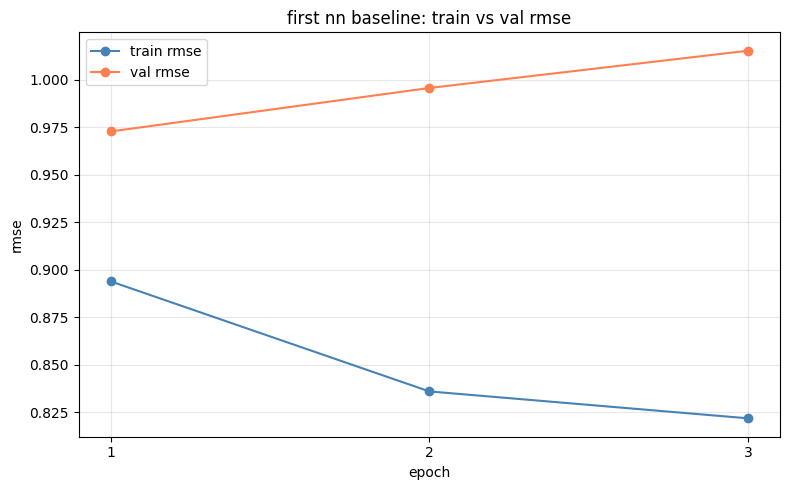


best val rmse: 0.9727 at epoch 1
final train-val gap: -0.1935


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
epochs = range(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, marker="o", label="train rmse", color="steelblue")
ax.plot(epochs, val_losses, marker="o", label="val rmse", color="coral")
ax.set_xlabel("epoch")
ax.set_ylabel("rmse")
ax.set_title("first nn baseline: train vs val rmse")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(list(epochs))
plt.tight_layout()
plt.show()

print(f"\nbest val rmse: {min(val_losses):.4f} at epoch {val_losses.index(min(val_losses)) + 1}")
print(f"final train-val gap: {train_losses[-1] - val_losses[-1]:.4f}")

first nn-only baseline. 32-dim user/movie embeddings, dot product + global mean offset, mse loss, adam lr=0.01. trained 3 epochs in ~7.5min on m5 mps. classic overfitting visible: train rmse drops 0.89 → 0.82 while val rmse rises 0.97 → 1.02. best val (0.9727) is at epoch 1. next iteration: add weight decay regularization, user/movie biases, early stopping, and refactor the training script for speed.